# Notebook 6: PBMC3k–PBMC4k Harmony integration

This notebook combines the two reviewed datasets without modifying either donor-specific analysis. It treats PBMC3k as **Donor 1** and PBMC4k as **Donor 2** as a project assumption; public source metadata does not verify that they are different people.

The goal is to reduce dataset-specific technical separation while preserving biological cell-type structure. Harmony is used only for the low-dimensional representation, neighbors, UMAP, and clustering. Original gene expression remains available for biological interpretation and future classifiers.

## 1. Imports, paths, and fixed settings

In [1]:
from pathlib import Path
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from scipy import sparse
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", figsize=(6, 5))
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
search_locations = [cwd, *cwd.parents]
root_candidates = []
for location in search_locations:
    root_candidates.extend([location, location / "26-the-backpropagators-analysis"])

ROOT = next(
    (
        candidate
        for candidate in root_candidates
        if (candidate / "PBMC3k").is_dir() and (candidate / "PBMC4k").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Could not locate the analysis repository. Open this notebook from inside "
        "26-the-backpropagators-analysis or its parent cosmos folder. "
        f"Current working directory: {cwd}"
    )
INTEGRATED_DIR = ROOT / "PBMC_integrated"
DATA_OUT = INTEGRATED_DIR / "data" / "processed"
FIG_OUT = INTEGRATED_DIR / "results" / "figures"
TABLE_OUT = INTEGRATED_DIR / "results" / "tables"
for directory in (DATA_OUT, FIG_OUT, TABLE_OUT):
    directory.mkdir(parents=True, exist_ok=True)

P3_ANNOTATED = ROOT / "PBMC3k" / "data" / "processed" / "pbmc3k_phase3_annotated.h5ad"
P4_ANNOTATED = ROOT / "PBMC4k" / "data" / "processed" / "pbmc4k_phase3_annotated.h5ad"
P3_RAW = ROOT / "PBMC3k" / "data" / "raw" / "filtered_gene_bc_matrices" / "hg19"
P4_RAW = ROOT / "PBMC4k" / "data" / "raw" / "filtered_gene_bc_matrices" / "GRCh38"

N_HVG = 2000
N_PCS = 50
N_NEIGHBORS = 15
LEIDEN_RESOLUTION = 0.5
RANDOM_STATE = 0

print(f"Repository root: {ROOT}")
print(f"Integrated outputs: {INTEGRATED_DIR}")

Repository root: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis
Integrated outputs: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated


## 2. Load reviewed metadata and original filtered counts

The reviewed objects determine which QC-passing cells are retained and provide the human-reviewed labels. Expression is rebuilt from the original count matrices so that both datasets receive exactly the same normalization.

In [2]:
reviewed3 = sc.read_h5ad(P3_ANNOTATED)
reviewed4 = sc.read_h5ad(P4_ANNOTATED)
raw3 = sc.read_10x_mtx(P3_RAW, var_names="gene_symbols", make_unique=True, cache=False)
raw4 = sc.read_10x_mtx(P4_RAW, var_names="gene_symbols", make_unique=True, cache=False)

required_obs = {"cell_type", "annotation_confidence"}
for name, obj in {"PBMC3k": reviewed3, "PBMC4k": reviewed4}.items():
    missing = required_obs.difference(obj.obs.columns)
    assert not missing, f"{name} is missing reviewed columns: {sorted(missing)}"

p3_barcodes = reviewed3.obs_names.astype(str)
p4_barcodes = reviewed4.obs["original_barcode"].astype(str).values
assert set(p3_barcodes).issubset(set(raw3.obs_names)), "Some reviewed PBMC3k cells are absent from raw counts."
assert set(p4_barcodes).issubset(set(raw4.obs_names)), "Some reviewed PBMC4k cells are absent from raw counts."

raw3 = raw3[p3_barcodes].copy()
raw4 = raw4[p4_barcodes].copy()
common_genes = pd.Index(sorted(set(raw3.var_names).intersection(raw4.var_names)))
assert common_genes.is_unique
raw3 = raw3[:, common_genes].copy()
raw4 = raw4[:, common_genes].copy()

print(f"Reviewed PBMC3k cells: {reviewed3.n_obs:,}")
print(f"Reviewed PBMC4k singlets: {reviewed4.n_obs:,}")
print(f"Shared genes: {len(common_genes):,}")

Reviewed PBMC3k cells: 2,638
Reviewed PBMC4k singlets: 4,131
Shared genes: 30,316


## 3. Build one compatible count matrix

Cell barcodes are prefixed to prevent collisions. The `dataset` and `donor` columns carry the batch identity used by Harmony. The reviewed `cell_type` labels are retained only for evaluation; Harmony does not use them.

In [3]:
keep_columns = [
    "n_genes_by_counts", "total_counts", "pct_counts_mt",
    "cell_type", "annotation_confidence",
]

def attach_metadata(counts, reviewed, dataset, donor, original_barcodes):
    out = counts.copy()
    metadata = reviewed.obs.reindex(reviewed.obs_names)[keep_columns].copy()
    metadata.index = out.obs_names
    metadata["original_barcode"] = np.asarray(original_barcodes, dtype=str)
    metadata["dataset"] = dataset
    metadata["donor"] = donor
    out.obs = metadata
    out.obs_names = pd.Index([f"{dataset.lower()}_{x}" for x in original_barcodes])
    return out

donor1 = attach_metadata(raw3, reviewed3, "PBMC3k", "Donor 1", p3_barcodes)
donor2 = attach_metadata(raw4, reviewed4, "PBMC4k", "Donor 2", p4_barcodes)
combined = ad.concat([donor1, donor2], join="inner", merge="same", index_unique=None)
combined.obs_names_make_unique()
combined.X = sparse.csr_matrix(combined.X)
combined.layers["counts"] = combined.X.copy()

for column in ["dataset", "donor", "cell_type", "annotation_confidence"]:
    combined.obs[column] = combined.obs[column].astype("category")

assert combined.n_obs == reviewed3.n_obs + reviewed4.n_obs
assert combined.obs_names.is_unique
combined.obs.rename(columns={"total_counts": "original_qc_total_counts"}, inplace=True)
combined.obs["shared_gene_total_counts"] = np.asarray(combined.layers["counts"].sum(axis=1)).ravel()

display(pd.crosstab(combined.obs["cell_type"], combined.obs["dataset"]))
display(combined.obs.groupby("dataset", observed=True)["shared_gene_total_counts"].describe())
print(combined)

dataset,PBMC3k,PBMC4k
cell_type,,
Activated/transitional T cells,128,1075
B cells,348,592
CD16+ non-classical monocytes,171,106
Classical monocytes,502,923
Cytotoxic CD8 T cells,273,588
Dendritic cells,0,34
IL7R+ memory/helper T cells,602,440
NK cells,153,181
Naive/resting T cells,450,192


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
PBMC3k,2638.0,2353.027588,982.936035,558.0,1767.25,2195.5,2746.0,8838.0
PBMC4k,4131.0,4000.531250,1499.292969,1366.0,3009.50,3771.0,4707.5,11036.0


AnnData object with n_obs × n_vars = 6769 × 30316
    obs: 'n_genes_by_counts', 'original_qc_total_counts', 'pct_counts_mt', 'cell_type', 'annotation_confidence', 'original_barcode', 'dataset', 'donor', 'shared_gene_total_counts'
    layers: 'counts'


## 4. Consistent normalization and batch-aware variable-gene selection

Every cell is normalized to 10,000 counts and log-transformed. Variable genes are selected with `dataset` as the batch key, which avoids selecting features solely because one dataset has a different technical profile. Full shared-gene normalized expression is retained in `.raw`; counts and normalized expression for the selected genes are also retained as layers.

In [4]:
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)
combined.raw = combined.copy()

sc.pp.highly_variable_genes(
    combined,
    flavor="seurat",
    n_top_genes=N_HVG,
    batch_key="dataset",
    subset=False,
)
hvg_summary = combined.var.loc[combined.var["highly_variable"], ["highly_variable_nbatches", "dispersions_norm"]].copy()
combined = combined[:, combined.var["highly_variable"]].copy()
combined.layers["log_normalized"] = combined.X.copy()
normalized_sum_before_harmony = float(combined.layers["log_normalized"].sum())

print(f"Selected highly variable genes: {combined.n_vars:,}")
print("Number of datasets in which selected genes were variable:")
display(hvg_summary["highly_variable_nbatches"].value_counts().sort_index().rename("genes").to_frame())

normalizing counts per cell


    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
Selected highly variable genes: 2,000
Number of datasets in which selected genes were variable:


,genes
highly_variable_nbatches,
1,1650
2,350


## 5. Uncorrected baseline

This baseline shows the joint structure before Harmony. It uses the same scaled expression and PCA that Harmony receives.

In [5]:
sc.pp.scale(combined, max_value=10)
sc.tl.pca(combined, n_comps=N_PCS, svd_solver="arpack", random_state=RANDOM_STATE)
combined.obsm["X_pca_uncorrected"] = combined.obsm["X_pca"].copy()

sc.pp.neighbors(
    combined,
    n_neighbors=N_NEIGHBORS,
    n_pcs=N_PCS,
    use_rep="X_pca_uncorrected",
    key_added="uncorrected",
    random_state=RANDOM_STATE,
)
sc.tl.umap(combined, neighbors_key="uncorrected", random_state=RANDOM_STATE)
combined.obsm["X_umap_uncorrected"] = combined.obsm["X_umap"].copy()
sc.tl.leiden(
    combined,
    resolution=LEIDEN_RESOLUTION,
    neighbors_key="uncorrected",
    key_added="leiden_uncorrected",
    random_state=RANDOM_STATE,
)

print(f"Uncorrected Leiden clusters: {combined.obs['leiden_uncorrected'].nunique()}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:04)
computing neighbors


/Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished (0:00:21)
computing UMAP
    finished (0:00:13)
running Leiden clustering
    finished (0:00:03)
Uncorrected Leiden clusters: 11


## 6. Harmony correction and corrected graph

Harmony adjusts the PCA coordinates using only `dataset`. Neighbors, UMAP, and Leiden are recalculated from those adjusted coordinates. Gene-expression matrices are not corrected or overwritten.

In [6]:
sce.pp.harmony_integrate(
    combined,
    key="dataset",
    basis="X_pca_uncorrected",
    adjusted_basis="X_pca_harmony",
    random_state=RANDOM_STATE,
    max_iter_harmony=20,
)

sc.pp.neighbors(
    combined,
    n_neighbors=N_NEIGHBORS,
    use_rep="X_pca_harmony",
    key_added="harmony",
    random_state=RANDOM_STATE,
)
sc.tl.umap(combined, neighbors_key="harmony", random_state=RANDOM_STATE)
combined.obsm["X_umap_harmony"] = combined.obsm["X_umap"].copy()
sc.tl.leiden(
    combined,
    resolution=LEIDEN_RESOLUTION,
    neighbors_key="harmony",
    key_added="leiden_harmony",
    random_state=RANDOM_STATE,
)

assert np.isclose(float(combined.layers["log_normalized"].sum()), normalized_sum_before_harmony)
print(f"Harmony Leiden clusters: {combined.obs['leiden_harmony'].nunique()}")
print("Normalized gene expression is unchanged by Harmony: yes")

2026-07-30 10:59:06,114 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-07-30 10:59:07,849 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-07-30 10:59:07,899 - harmonypy - INFO - Iteration 1 of 20
2026-07-30 10:59:10,001 - harmonypy - INFO - Iteration 2 of 20
2026-07-30 10:59:11,696 - harmonypy - INFO - Iteration 3 of 20
2026-07-30 10:59:14,017 - harmonypy - INFO - Converged after 3 iterations


computing neighbors
    finished (0:00:00)
computing UMAP
    finished (0:00:12)
running Leiden clustering
    finished (0:00:03)
Harmony Leiden clusters: 9
Normalized gene expression is unchanged by Harmony: yes


## 7. Before/after visual comparison

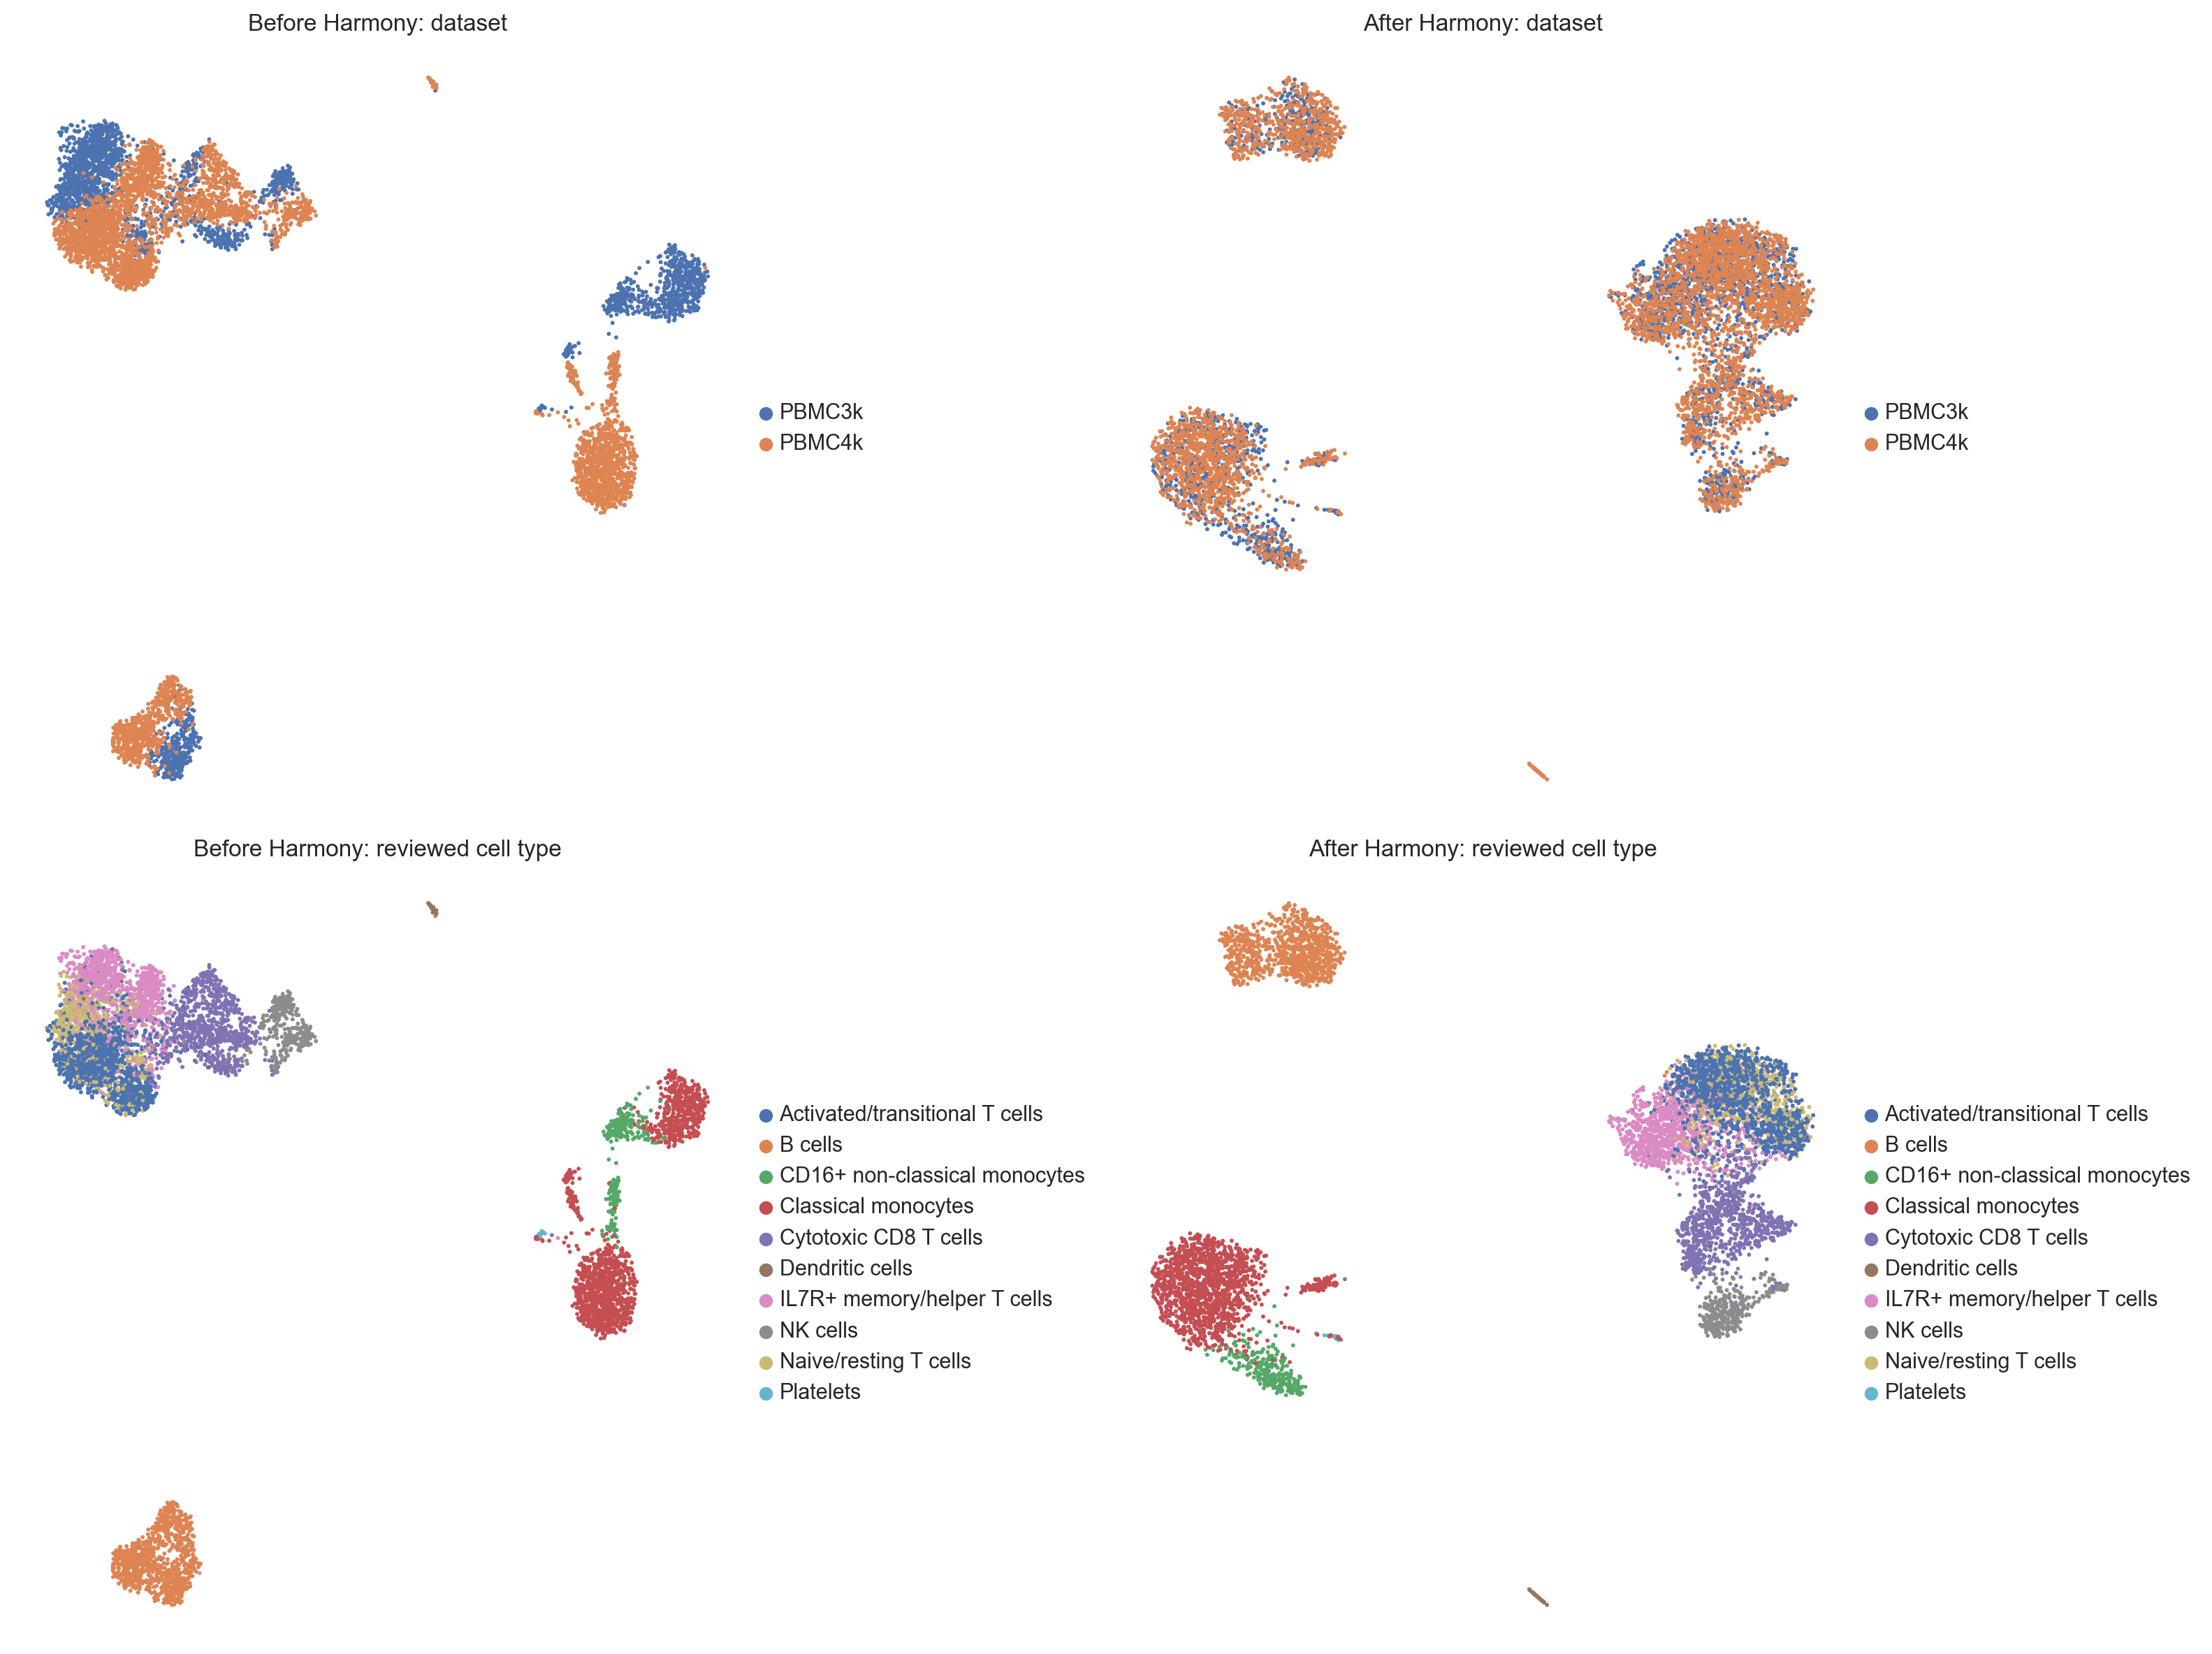

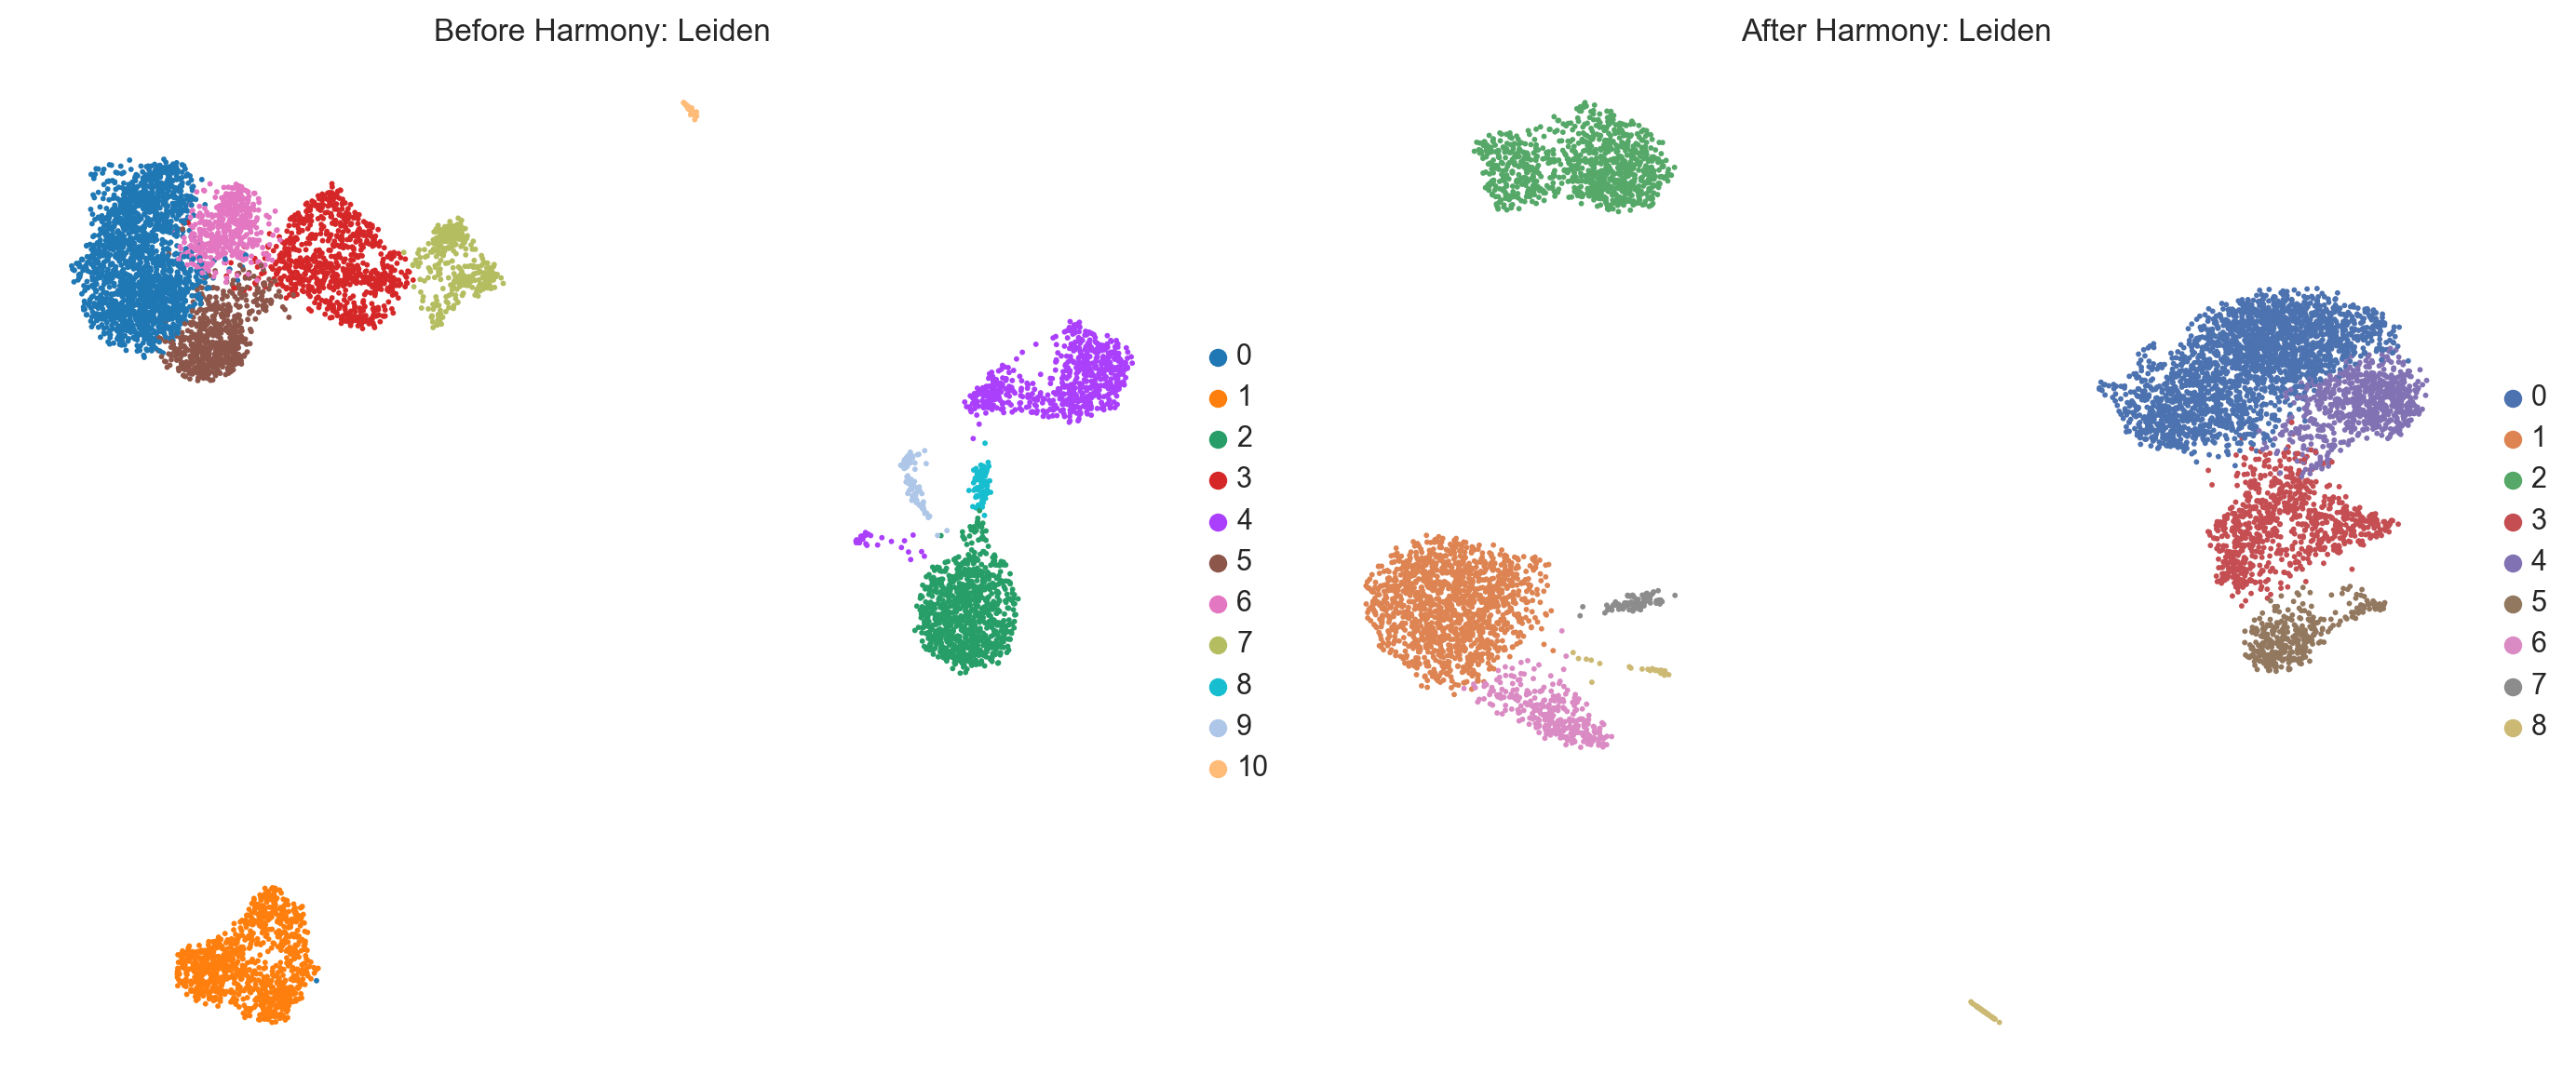

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_specs = [
    ("umap_uncorrected", "dataset", "Before Harmony: dataset"),
    ("umap_harmony", "dataset", "After Harmony: dataset"),
    ("umap_uncorrected", "cell_type", "Before Harmony: reviewed cell type"),
    ("umap_harmony", "cell_type", "After Harmony: reviewed cell type"),
]
for ax, (basis, color, title) in zip(axes.flat, plot_specs):
    sc.pl.embedding(combined, basis=basis, color=color, ax=ax, show=False, title=title, frameon=False)
fig.tight_layout()
fig.savefig(FIG_OUT / "pbmc_integrated_harmony_before_after.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(combined, basis="umap_uncorrected", color="leiden_uncorrected", ax=axes[0], show=False, title="Before Harmony: Leiden", frameon=False)
sc.pl.embedding(combined, basis="umap_harmony", color="leiden_harmony", ax=axes[1], show=False, title="After Harmony: Leiden", frameon=False)
fig.tight_layout()
fig.savefig(FIG_OUT / "pbmc_integrated_harmony_clusters.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Quantitative integration review

No single score proves a good integration. We want **lower dataset separation**, **higher cross-dataset neighborhood mixing**, and **stable cell-type structure**. Scores are therefore reported together.

- Dataset silhouette: lower is less separable by dataset.
- Cross-dataset neighbor fraction: higher means more mixing.
- Cell-type silhouette and neighbor purity: higher means biology remains separated.
- Cluster–dataset NMI: lower means clusters are less determined by dataset.
- Cluster–cell-type ARI/NMI: higher means clusters agree better with reviewed biology.

In [8]:
def neighbor_indices(representation, n_neighbors=N_NEIGHBORS):
    model = NearestNeighbors(n_neighbors=n_neighbors + 1, metric="euclidean")
    indices = model.fit(representation).kneighbors(return_distance=False)
    return indices[:, 1:]

def representation_metrics(adata, representation, cluster_key, stage):
    rep = np.asarray(adata.obsm[representation])
    neighbors = neighbor_indices(rep)
    datasets = adata.obs["dataset"].astype(str).to_numpy()
    labels = adata.obs["cell_type"].astype(str).to_numpy()
    clusters = adata.obs[cluster_key].astype(str).to_numpy()
    rng = np.random.default_rng(RANDOM_STATE)
    sample = rng.choice(adata.n_obs, size=min(3000, adata.n_obs), replace=False)
    return {
        "stage": stage,
        "dataset_silhouette": silhouette_score(rep[sample], datasets[sample]),
        "cross_dataset_neighbor_fraction": np.mean(datasets[neighbors] != datasets[:, None]),
        "cell_type_silhouette": silhouette_score(rep[sample], labels[sample]),
        "cell_type_neighbor_purity": np.mean(labels[neighbors] == labels[:, None]),
        "cluster_dataset_nmi": normalized_mutual_info_score(datasets, clusters),
        "cluster_cell_type_ari": adjusted_rand_score(labels, clusters),
        "cluster_cell_type_nmi": normalized_mutual_info_score(labels, clusters),
        "n_clusters": len(np.unique(clusters)),
    }

metrics = pd.DataFrame([
    representation_metrics(combined, "X_pca_uncorrected", "leiden_uncorrected", "Before Harmony"),
    representation_metrics(combined, "X_pca_harmony", "leiden_harmony", "After Harmony"),
]).set_index("stage")
display(metrics.round(4))
metrics.to_csv(TABLE_OUT / "pbmc_integrated_harmony_metrics.csv")

,dataset_silhouette,cross_dataset_neighbor_fraction,cell_type_silhouette,cell_type_neighbor_purity,cluster_dataset_nmi,cluster_cell_type_ari,cluster_cell_type_nmi,n_clusters
stage,,,,,,,,
Before Harmony,0.0323,0.0938,0.0878,0.8161,0.1421,0.5100,0.6878,11
After Harmony,0.0029,0.4448,0.0915,0.7705,0.0063,0.5929,0.7354,9


## 9. Cell-type-specific donor mixing

For each cell type found in both datasets, this measures the fraction of its nearest same-type neighbors that come from the other dataset. Platelets occur only in PBMC3k and dendritic cells only in PBMC4k, so they are intentionally reported as dataset-specific rather than treated as integration failures.

stage,After Harmony,Before Harmony
cell_type,,
Activated/transitional T cells,0.0986,0.0603
B cells,0.4587,0.1255
CD16+ non-classical monocytes,0.4640,0.0207
Classical monocytes,0.4411,0.0108
Cytotoxic CD8 T cells,0.4188,0.1230
Dendritic cells,NaN,NaN
IL7R+ memory/helper T cells,0.4553,0.0887
NK cells,0.4671,0.0854
Naive/resting T cells,0.3166,0.0965


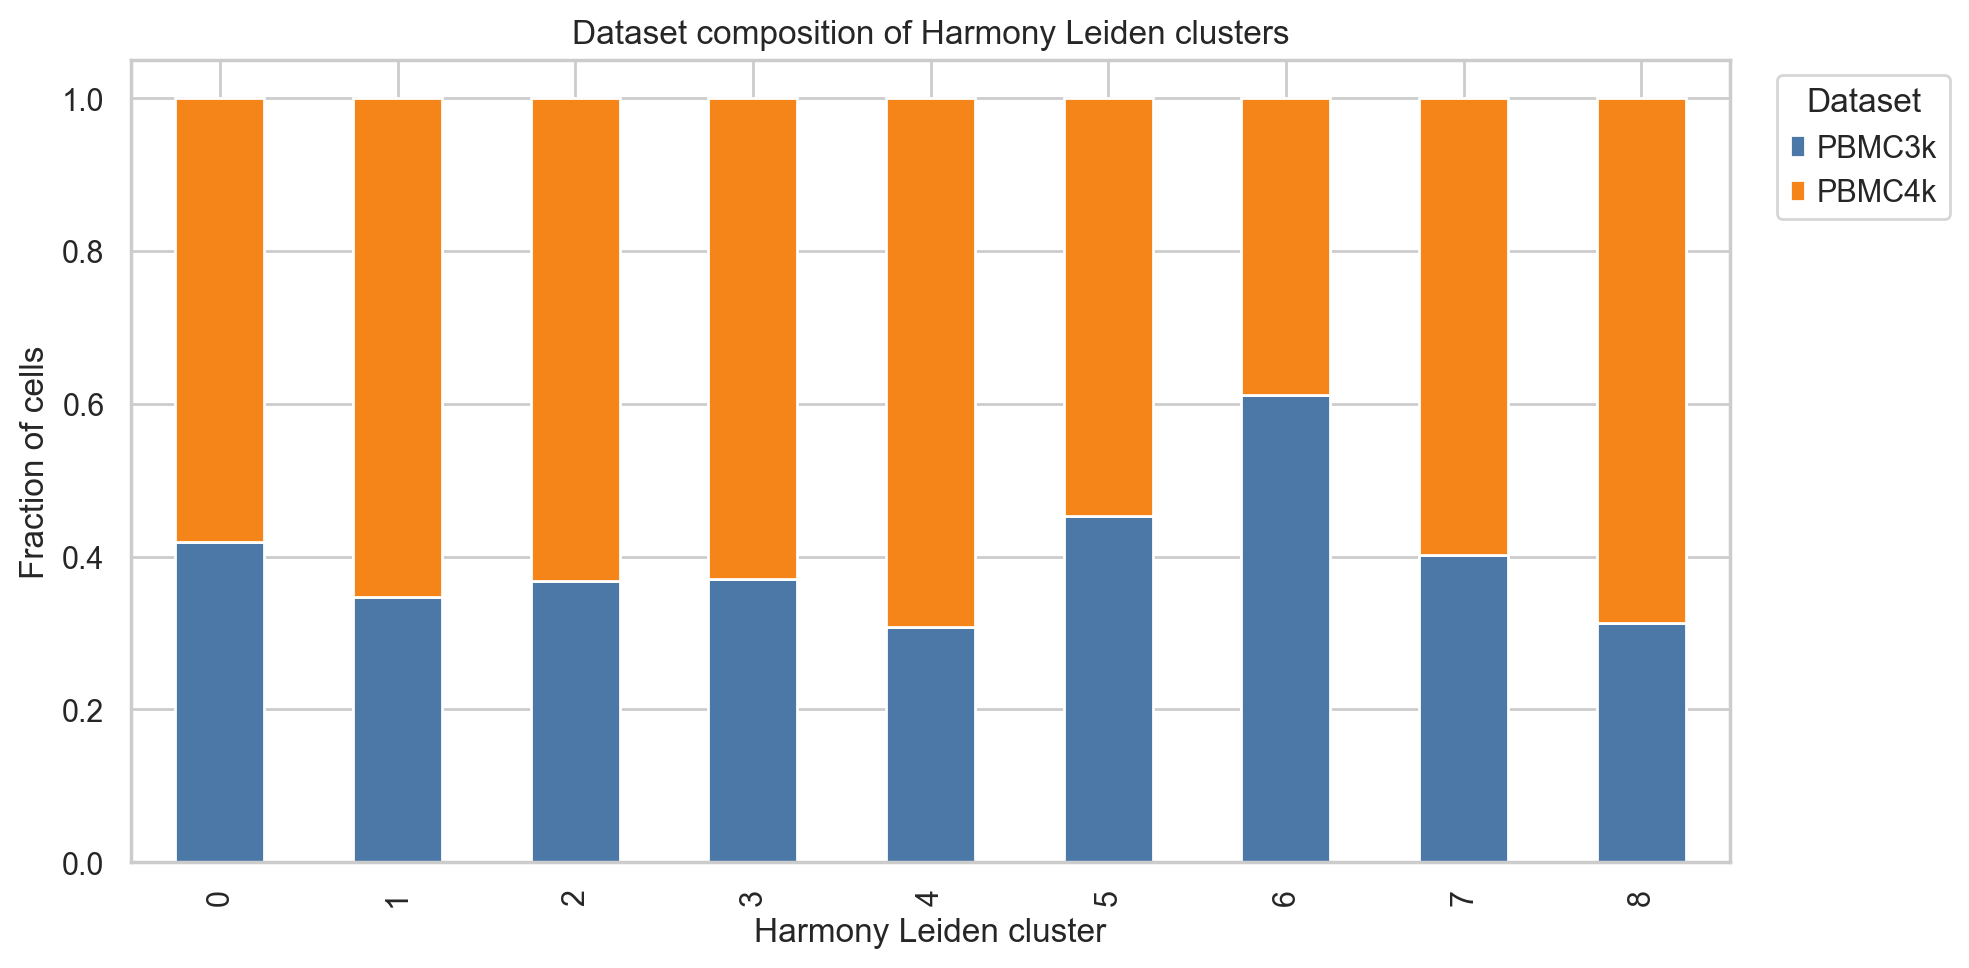

In [9]:
def within_type_mixing(adata, representation, stage):
    rows = []
    rep = np.asarray(adata.obsm[representation])
    for cell_type, positions in adata.obs.groupby("cell_type", observed=True).indices.items():
        positions = np.asarray(positions)
        type_datasets = adata.obs.iloc[positions]["dataset"].astype(str).to_numpy()
        present = np.unique(type_datasets)
        row = {
            "stage": stage,
            "cell_type": str(cell_type),
            "n_cells": len(positions),
            "datasets_present": len(present),
            "cross_dataset_neighbor_fraction": np.nan,
        }
        if len(present) == 2 and len(positions) > 2:
            k = min(N_NEIGHBORS, len(positions) - 1)
            idx = NearestNeighbors(n_neighbors=k + 1).fit(rep[positions]).kneighbors(return_distance=False)[:, 1:]
            row["cross_dataset_neighbor_fraction"] = np.mean(type_datasets[idx] != type_datasets[:, None])
        rows.append(row)
    return pd.DataFrame(rows)

mixing_by_type = pd.concat([
    within_type_mixing(combined, "X_pca_uncorrected", "Before Harmony"),
    within_type_mixing(combined, "X_pca_harmony", "After Harmony"),
], ignore_index=True)
mixing_pivot = mixing_by_type.pivot(index="cell_type", columns="stage", values="cross_dataset_neighbor_fraction")
display(mixing_pivot.round(4))
mixing_by_type.to_csv(TABLE_OUT / "pbmc_integrated_harmony_cell_type_mixing.csv", index=False)

cluster_composition = pd.crosstab(
    combined.obs["leiden_harmony"], combined.obs["dataset"], normalize="index"
)
cluster_counts = pd.crosstab(combined.obs["leiden_harmony"], combined.obs["dataset"])
cluster_counts.to_csv(TABLE_OUT / "pbmc_integrated_harmony_cluster_dataset_counts.csv")
cluster_composition.to_csv(TABLE_OUT / "pbmc_integrated_harmony_cluster_dataset_proportions.csv")

ax = cluster_composition.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#4C78A8", "#F58518"])
ax.set(title="Dataset composition of Harmony Leiden clusters", xlabel="Harmony Leiden cluster", ylabel="Fraction of cells")
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_OUT / "pbmc_integrated_harmony_cluster_dataset_composition.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Rare-population clustering sensitivity

Dendritic cells occur only in PBMC4k and platelets occur only in PBMC3k. Because Harmony cannot observe a counterpart for either population, their cluster assignments require special review. The primary resolution remains 0.5 for consistency, while nearby resolutions test whether an apparent rare-population merger is resolution-dependent.

In [10]:
rare_types = ["Dendritic cells", "Platelets"]
rare_rows = []
for resolution in [0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    key = f"leiden_harmony_sensitivity_{str(resolution).replace('.', '_')}"
    sc.tl.leiden(
        combined,
        resolution=resolution,
        neighbors_key="harmony",
        key_added=key,
        random_state=RANDOM_STATE,
    )
    dominant = {}
    for cell_type in rare_types:
        values = combined.obs.loc[combined.obs["cell_type"] == cell_type, key]
        dominant[cell_type] = str(values.value_counts().index[0])
    rare_rows.append({
        "resolution": resolution,
        "n_clusters": combined.obs[key].nunique(),
        "dendritic_dominant_cluster": dominant["Dendritic cells"],
        "platelet_dominant_cluster": dominant["Platelets"],
        "rare_dominant_clusters_separated": dominant["Dendritic cells"] != dominant["Platelets"],
    })
    if np.isclose(resolution, 0.6):
        combined.obs["leiden_harmony_r0_6"] = combined.obs[key].copy()
    del combined.obs[key]

rare_sensitivity = pd.DataFrame(rare_rows)
rare_sensitivity.to_csv(TABLE_OUT / "pbmc_integrated_harmony_rare_resolution_sensitivity.csv", index=False)
display(rare_sensitivity)

rare_separated_primary = bool(rare_sensitivity.loc[np.isclose(rare_sensitivity["resolution"], 0.5), "rare_dominant_clusters_separated"].iloc[0])
rare_separated_r06 = bool(rare_sensitivity.loc[np.isclose(rare_sensitivity["resolution"], 0.6), "rare_dominant_clusters_separated"].iloc[0])
print(f"Primary resolution 0.5 separates dendritic cells and platelets: {rare_separated_primary}")
print(f"Sensitivity resolution 0.6 separates dendritic cells and platelets: {rare_separated_r06}")
print("Use resolution 0.6 when a cluster-level view of these rare populations is important; do not strengthen Harmony merely to force the result.")

running Leiden clustering
    finished (0:00:03)
running Leiden clustering
    finished (0:00:04)
running Leiden clustering
    finished (0:00:02)
running Leiden clustering
    finished (0:00:04)
running Leiden clustering
    finished (0:00:02)
running Leiden clustering
    finished (0:00:03)


,resolution,n_clusters,dendritic_dominant_cluster,platelet_dominant_cluster,rare_dominant_clusters_separated
0,0.4,8,7,7,False
1,0.5,9,8,8,False
2,0.6,10,8,9,True
3,0.7,11,9,10,True
4,0.8,10,8,9,True
5,1.0,11,9,10,True


Primary resolution 0.5 separates dendritic cells and platelets: False
Sensitivity resolution 0.6 separates dendritic cells and platelets: True
Use resolution 0.6 when a cluster-level view of these rare populations is important; do not strengthen Harmony merely to force the result.


## 11. Save the integrated object and interpretation summary

The saved object contains original selected-gene counts, normalized selected-gene expression, full shared-gene normalized expression in `.raw`, uncorrected and Harmony PCA/UMAP representations, both neighbor graphs, and both Leiden solutions. The donor-specific input files are never overwritten.

In [11]:
combined.uns["integration_assumptions"] = {
    "PBMC3k": "Donor 1 (project assumption, not verified source identity)",
    "PBMC4k": "Donor 2 (project assumption, not verified source identity)",
    "harmony_batch_key": "dataset",
    "classifier_feature_policy": "Use normalized genes, never Harmony coordinates",
}
combined.uns["integration_settings"] = {
    "normalization_target_sum": 10000,
    "n_highly_variable_genes": N_HVG,
    "n_pcs": N_PCS,
    "n_neighbors": N_NEIGHBORS,
    "leiden_resolution": LEIDEN_RESOLUTION,
    "rare_population_sensitivity_resolution": 0.6,
    "random_state": RANDOM_STATE,
}

output_path = DATA_OUT / "pbmc3k_pbmc4k_harmony_integrated.h5ad"
combined.write_h5ad(output_path, compression="gzip")

before = metrics.loc["Before Harmony"]
after = metrics.loc["After Harmony"]
summary = pd.DataFrame({
    "check": [
        "Dataset silhouette decreased",
        "Cross-dataset neighbor mixing increased",
        "Cell-type neighbor purity retained",
        "Cluster association with dataset decreased",
        "Normalized expression unchanged",
        "Rare populations separated at primary resolution 0.5",
        "Rare populations separated at sensitivity resolution 0.6",
    ],
    "passed": [
        after["dataset_silhouette"] < before["dataset_silhouette"],
        after["cross_dataset_neighbor_fraction"] > before["cross_dataset_neighbor_fraction"],
        after["cell_type_neighbor_purity"] >= before["cell_type_neighbor_purity"] - 0.05,
        after["cluster_dataset_nmi"] < before["cluster_dataset_nmi"],
        np.isclose(float(combined.layers["log_normalized"].sum()), normalized_sum_before_harmony),
        rare_separated_primary,
        rare_separated_r06,
    ],
})
summary.to_csv(TABLE_OUT / "pbmc_integrated_harmony_review_checklist.csv", index=False)
display(summary)
print(f"Saved integrated object: {output_path}")
print("\nInterpret the score table and UMAPs together. A failed checklist item is a review flag, not an automatic reason to force stronger correction.")

,check,passed
0,Dataset silhouette decreased,True
1,Cross-dataset neighbor mixing increased,True
2,Cell-type neighbor purity retained,True
3,Cluster association with dataset decreased,True
4,Normalized expression unchanged,True
5,Rare populations separated at primary resoluti...,False
6,Rare populations separated at sensitivity reso...,True


Saved integrated object: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC_integrated/data/processed/pbmc3k_pbmc4k_harmony_integrated.h5ad

Interpret the score table and UMAPs together. A failed checklist item is a review flag, not an automatic reason to force stronger correction.


## What this notebook does not do

- It does not change the original PBMC3k or PBMC4k analyses.
- It does not retrain or overwrite the PBMC3k XGBoost model.
- It does not use a train/test split, because Harmony is unsupervised integration.
- It does not use Harmony coordinates as classifier inputs.
- It does not claim that dataset differences are biological donor differences, because donor and technical batch are confounded.